In [10]:
# Importamos herramientas de COBAYA
from cobaya.run import run
from cobaya.yaml import yaml_load

# Para funciones matemáticas dentro del YAML
import numpy as np

In [11]:
!cobaya-install cosmo -p /path/to/packages

[install] Installing basic cosmological packages.
[install] Installing external packages at 'C:\path\to\packages'
[install] The installation path has been written into the global config file: C:\Users\yo\AppData\Local\cobaya\config.yaml

theory:camb

[install] Checking if dependencies have already been installed...
[install] Check found no existing installation
[install] (If you expected this to be already installed, re-run `cobaya-install` with --debug to get more verbose output.)
[install] Installing...
[CAMB] Installing pre-requisites...
[CAMB] Downloading camb...
[CAMB] Downloaded filename CAMB-master.tar.gz
[CAMB] CAMB master downloaded and decompressed correctly.
[CAMB] Compiling camb...
[CAMB] running build_cluster


[CAMB] C:\Users\yo\miniconda3\envs\cmb\Lib\site-packages\wheel\bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later 


0.00iB [00:00, ?iB/s]
64.5kiB [00:00, 614kiB/s]
128kiB [00:00, 619kiB/s] 
256kiB [00:00, 905kiB/s]
480kiB [00:00, 1.41MiB/s]
640kiB [00:00, 872kiB/s] 
880kiB [00:00, 1.21MiB/s]
1.06MiB [00:00, 1.41MiB/s]
1.36MiB [00:01, 1.81MiB/s]
1.64MiB [00:01, 2.07MiB/s]
1.91MiB [00:01, 2.22MiB/s]
2.20MiB [00:01, 2.42MiB/s]
2.48MiB [00:01, 2.54MiB/s]
2.77MiB [00:01, 2.60MiB/s]
3.06MiB [00:01, 2.73MiB/s]
3.34MiB [00:01, 2.75MiB/s]
3.62MiB [00:01, 2.77MiB/s]
3.95MiB [00:01, 2.91MiB/s]
4.23MiB [00:02, 2.87MiB/s]
4.55MiB [00:02, 2.93MiB/s]
4.84MiB [00:02, 2.93MiB/s]
5.16MiB [00:02, 2.98MiB/s]
5.48MiB [00:02, 3.06MiB/s]
5.78MiB [00:02, 2.81MiB/s]
6.11MiB [00:02, 2.88MiB/s]
6.42MiB [00:02, 2.91MiB/s]
6.73MiB [00:02, 2.95MiB/s]
7.06MiB [00:03, 2.92MiB/s]
7.36MiB [00:03, 2.78MiB/s]
7.70MiB [00:03, 2.79MiB/s]
8.02MiB [00:03, 2.77MiB/s]
8.36MiB [00:03, 2.92MiB/s]
8.70MiB [00:03, 3.04MiB/s]
9.03MiB [00:03, 3.15MiB/s]
9.36MiB [00:03, 3.19MiB/s]
9.70MiB [00:04, 3.23MiB/s]
10.0MiB [00:04, 3.27MiB/s]
10.4MiB [00:

In [12]:
# Comenzar definiendo un nuevo diccionario de configuración en Python
# Formato tipo YAML y luego convertirlo a un diccionario de Python

# El modelo LCDM tiene 6 parámetros, por lo que debes defin al menos 6
# parámetros que serán muestreados dentro del bloque `params`

# Comenzamos definiendo un nuevo diccionario de configuración llamado `info_cosmo`
info_cosmo = {
'likelihood': {'bao.sdss_dr16_baoplus_elg': None,
                'bao.sdss_dr16_baoplus_lrg': None,
                'bao.sdss_dr16_baoplus_lyauto': None,
                'bao.sdss_dr16_baoplus_lyxqso': None,
                'bao.sdss_dr16_baoplus_qso': None,
                'bao.sdss_dr7_mgs': None,
                'bao.sixdf_2011_bao': None,
                'planck_NPIPE_highl_CamSpec.TTTEEE.TTTEEE': None,
                'planckpr4lensing': None,
                'planck_2018_lowl.EE': None,
                'planck_2018_lowl.TT': None,
                'sn.pantheon': None},
'params': {'A': {'derived': 'lambda As: 1e9*As',
                  'latex': '10^9 A_\\mathrm{s}'},
            'As': {'latex': 'A_\\mathrm{s}',
                   'value': 'lambda logA: 1e-10*np.exp(logA)'},
            'DHBBN': {'derived': 'lambda DH: 10**5*DH',
                      'latex': '10^5 \\mathrm{D}/\\mathrm{H}'},
            'H0': {'latex': 'H_0', 'max': 100, 'min': 20},
            'YHe': {'latex': 'Y_\\mathrm{P}'},
            'Y_p': {'latex': 'Y_P^\\mathrm{BBN}'},
            'age': {'latex': '{\\rm{Age}}/\\mathrm{Gyr}'},
            'clamp': {'derived': 'lambda As, tau: 1e9*As*np.exp(-2*tau)',
                      'latex': '10^9 A_\\mathrm{s} e^{-2\\tau}'},
            'cosmomc_theta': {'derived': False,
                              'value': 'lambda theta_MC_100: '
                                       '1.e-2*theta_MC_100'},
            'logA': {'drop': True,
                     'latex': '\\log(10^{10} A_\\mathrm{s})',
                     'prior': {'max': 3.91, 'min': 1.61},
                     'proposal': 0.001,
                     'ref': {'dist': 'norm', 'loc': 3.05, 'scale': 0.001}},
            'mnu': 0.06,
            'ns': {'latex': 'n_\\mathrm{s}',
                   'prior': {'max': 1.2, 'min': 0.8},
                   'proposal': 0.002,
                   'ref': {'dist': 'norm', 'loc': 0.965, 'scale': 0.004}}, #es el punto desde donde empieza la cadena
            'ombh2': {'latex': '\\Omega_\\mathrm{b} h^2',
                      'prior': {'max': 0.1, 'min': 0.005},
                      'proposal': 0.0001, #tamaño del salto de la cadena
                      'ref': {'dist': 'norm', 'loc': 0.0224, 'scale': 0.0001}},
            'omch2': {'latex': '\\Omega_\\mathrm{c} h^2',
                      'prior': {'max': 0.99, 'min': 0.001},
                      'proposal': 0.0005,
                      'ref': {'dist': 'norm', 'loc': 0.12, 'scale': 0.001}},
            'omega_de': {'latex': '\\Omega_\\Lambda'},
            'omegam': {'latex': '\\Omega_\\mathrm{m}'},
            'omegamh2': {'derived': 'lambda omegam, H0: omegam*(H0/100)**2',
                         'latex': '\\Omega_\\mathrm{m} h^2'},
            'rdrag': {'latex': 'r_\\mathrm{drag}'},
            's8h5': {'derived': 'lambda sigma8, H0: sigma8*(H0*1e-2)**(-0.5)',
                     'latex': '\\sigma_8/h^{0.5}'},
            's8omegamp25': {'derived': 'lambda sigma8, omegam: '
                                       'sigma8*omegam**0.25',
                            'latex': '\\sigma_8 \\Omega_\\mathrm{m}^{0.25}'},
            's8omegamp5': {'derived': 'lambda sigma8, omegam: '
                                      'sigma8*omegam**0.5',
                           'latex': '\\sigma_8 \\Omega_\\mathrm{m}^{0.5}'},
            'sigma8': {'latex': '\\sigma_8'},
            'tau': {'latex': '\\tau_\\mathrm{reio}',
                    'prior': {'max': 0.8, 'min': 0.01},
                    'proposal': 0.003,
                    'ref': {'dist': 'norm', 'loc': 0.055, 'scale': 0.006}},
            'theta_MC_100': {'drop': True,
                             'latex': '100\\theta_\\mathrm{MC}',
                             'prior': {'max': 10, 'min': 0.5},
                             'proposal': 0.0002,
                             'ref': {'dist': 'norm',
                                     'loc': 1.04109,
                                     'scale': 0.0004},
                             'renames': 'theta'},
            'zrei': {'latex': 'z_\\mathrm{re}'}},
'sampler': {'evaluate': None},
'output': 'chains/lcdm_run',
'force': True,
'theory': {'camb': {'extra_args': {'bbn_predictor': 'PArthENoPE_880.2_standard.dat',
                                    'halofit_version': 'mead',
                                    'lens_potential_accuracy': 1,
                                    'nnu': 3.046,
                                    'num_massive_neutrinos': 1,
                                    'theta_H0_range': [20, 100]}}}}



In [13]:
# Run Cobaya!
updated_info_cosmo, sampler_cosmo = run(info_cosmo)

[output] Output to be read-from/written-into folder 'chains', with prefix 'lcdm_run'
[output] Found existing info files with the requested output prefix: 'chains/lcdm_run'
[output] Will delete previous products ('force' was requested).
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\envs\cmb\Lib\site-packages\camb
[bao.sdss_dr16_baoplus_lrg] Initialized.
[bao.sdss_dr16_baoplus_qso] Initialized.
[bao.sixdf_2011_bao] Initialized.
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 143x143: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 217x217: 500 2500
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 143x217: 500 2500
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for TE: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for EE: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] Number of data points: 9915
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   logA = 

In [16]:
info_cosmo = {
'likelihood': {'bao.sdss_dr16_baoplus_elg': None,
                'bao.sdss_dr16_baoplus_lrg': None,
                'bao.sdss_dr16_baoplus_lyauto': None,
                'bao.sdss_dr16_baoplus_lyxqso': None,
                'bao.sdss_dr16_baoplus_qso': None,
                'bao.sdss_dr7_mgs': None,
                'bao.sixdf_2011_bao': None,
                'planck_NPIPE_highl_CamSpec.TTTEEE.TTTEEE': None,
                'planckpr4lensing': None,
                'planck_2018_lowl.EE': None,
                'planck_2018_lowl.TT': None,
                'sn.pantheon': None},
'params': {'A': {'derived': 'lambda As: 1e9*As',
                  'latex': '10^9 A_\\mathrm{s}'},
            'As': {'latex': 'A_\\mathrm{s}',
                   'value': 'lambda logA: 1e-10*np.exp(logA)'},
            'DHBBN': {'derived': 'lambda DH: 10**5*DH',
                      'latex': '10^5 \\mathrm{D}/\\mathrm{H}'},
            'H0': {'latex': 'H_0', 'max': 100, 'min': 20},
            'YHe': {'latex': 'Y_\\mathrm{P}'},
            'Y_p': {'latex': 'Y_P^\\mathrm{BBN}'},
            'age': {'latex': '{\\rm{Age}}/\\mathrm{Gyr}'},
            'clamp': {'derived': 'lambda As, tau: 1e9*As*np.exp(-2*tau)',
                      'latex': '10^9 A_\\mathrm{s} e^{-2\\tau}'},
            'cosmomc_theta': {'derived': False,
                              'value': 'lambda theta_MC_100: '
                                       '1.e-2*theta_MC_100'},
            'logA': {'drop': True,
                     'latex': '\\log(10^{10} A_\\mathrm{s})',
                     'prior': {'max': 3.91, 'min': 1.61},
                     'proposal': 0.001,
                     'ref': {'dist': 'norm', 'loc': 3.05, 'scale': 0.001}},
            'mnu': 0.06,
            'ns': {'latex': 'n_\\mathrm{s}',
                   'prior': {'max': 1.2, 'min': 0.8},
                   'proposal': 0.002,
                   'ref': {'dist': 'norm', 'loc': 0.965, 'scale': 0.004}},
            'ombh2': {'latex': '\\Omega_\\mathrm{b} h^2',
                      'prior': {'max': 0.1, 'min': 0.005},
                      'proposal': 0.0001,
                      'ref': {'dist': 'norm', 'loc': 0.0224, 'scale': 0.0001}},
            'omch2': {'latex': '\\Omega_\\mathrm{c} h^2',
                      'prior': {'max': 0.99, 'min': 0.001},
                      'proposal': 0.0005,
                      'ref': {'dist': 'norm', 'loc': 0.12, 'scale': 0.001}},
            'omega_de': {'latex': '\\Omega_\\Lambda'},
            'omegam': {'latex': '\\Omega_\\mathrm{m}'},
            'omegamh2': {'derived': 'lambda omegam, H0: omegam*(H0/100)**2',
                         'latex': '\\Omega_\\mathrm{m} h^2'},
            'rdrag': {'latex': 'r_\\mathrm{drag}'},
            's8h5': {'derived': 'lambda sigma8, H0: sigma8*(H0*1e-2)**(-0.5)',
                     'latex': '\\sigma_8/h^{0.5}'},
            's8omegamp25': {'derived': 'lambda sigma8, omegam: '
                                       'sigma8*omegam**0.25',
                            'latex': '\\sigma_8 \\Omega_\\mathrm{m}^{0.25}'},
            's8omegamp5': {'derived': 'lambda sigma8, omegam: '
                                      'sigma8*omegam**0.5',
                           'latex': '\\sigma_8 \\Omega_\\mathrm{m}^{0.5}'},
            'sigma8': {'latex': '\\sigma_8'},
            'tau': {'latex': '\\tau_\\mathrm{reio}',
                    'prior': {'max': 0.8, 'min': 0.01},
                    'proposal': 0.003,
                    'ref': {'dist': 'norm', 'loc': 0.055, 'scale': 0.006}},
            'theta_MC_100': {'drop': True,
                             'latex': '100\\theta_\\mathrm{MC}',
                             'prior': {'max': 10, 'min': 0.5},
                             'proposal': 0.0002,
                             'ref': {'dist': 'norm',
                                     'loc': 1.04109,
                                     'scale': 0.0004},
                             'renames': 'theta'},
            'zrei': {'latex': 'z_\\mathrm{re}'}},
'sampler': {'mcmc': {'max_samples': 10000}},
'output': 'chains/lcdm_run',
'force': True,
'theory': {'camb': {'extra_args': {'bbn_predictor': 'PArthENoPE_880.2_standard.dat',
                                    'halofit_version': 'mead',
                                    'lens_potential_accuracy': 1,
                                    'nnu': 3.046,
                                    'num_massive_neutrinos': 1,
                                    'theta_H0_range': [20, 100]}}}}

In [17]:
# Run Cobaya!
updated_info_cosmo, sampler_cosmo = run(info_cosmo)

[output] Output to be read-from/written-into folder 'chains', with prefix 'lcdm_run'
[output] Found existing info files with the requested output prefix: 'chains/lcdm_run'
[output] Will delete previous products ('force' was requested).
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\envs\cmb\Lib\site-packages\camb
[bao.sdss_dr16_baoplus_lrg] Initialized.
[bao.sdss_dr16_baoplus_qso] Initialized.
[bao.sixdf_2011_bao] Initialized.
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 143x143: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 217x217: 500 2500
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 143x217: 500 2500
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for TE: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for EE: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] Number of data points: 9915
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: logA:3.049369, ns:0.9651463, ombh2:0.022

In [1]:
from cobaya.run import run
import numpy as np

# CONFIGURACIÓN DEL MODELO COSMOLÓGICO
# Aquí definimos qué datos usar, qué parámetros variar,
# y cómo correr el MCMC.

info_cosmo = {

    # LIKELIHOODS (datos observacionales)
    'likelihood': {

        # Mantuve Planck + BAO + supernovas.
        # Quité planckpr4lensing porque antes me daba error de instalación.

        'planck_NPIPE_highl_CamSpec.TTTEEE.TTTEEE': None,
        'planck_2018_lowl.EE': None,
        'planck_2018_lowl.TT': None,

        'bao.sdss_dr16_baoplus_lrg': None,
        'bao.sdss_dr16_baoplus_qso': None,
        'bao.sixdf_2011_bao': None,

        'sn.pantheon': None
    },

    # PARÁMETROS COSMOLÓGICOS
    'params': {

        # As: amplitud escalar primordial
        # igual que en el código:
        # Cobaya samplea logA y de ahí calcula As.
        'As': {
            'value': 'lambda logA: 1e-10*np.exp(logA)'
        },

        # logA
        # CAMBIO:
        # Antes el prior era demasiado ancho.
        # Ahora lo acoté cerca del valor de Planck (~3.05),
        # para que el MCMC no pruebe universos absurdos.
        'logA': {
            'prior': {'min': 2.8, 'max': 3.3},
            'ref': {'dist': 'norm', 'loc': 3.05, 'scale': 0.02},
            'proposal': 0.02,
            'drop': True
        },

        # ns
        # índice espectral.
        # Acotado a rango físicamente razonable.
        'ns': {
            'prior': {'min': 0.92, 'max': 1.00},
            'ref': {'dist': 'norm', 'loc': 0.965, 'scale': 0.01},
            'proposal': 0.005
        },

        # ombh2
        # densidad bariónica.
        # CAMBIO importante:
        # prior era muy amplio y hacía fallar el punto inicial.
        'ombh2': {
            'prior': {'min': 0.021, 'max': 0.024},
            'ref': {'dist': 'norm', 'loc': 0.0224, 'scale': 0.0002},
            'proposal': 0.00015
        },

        # omch2
        # densidad de materia oscura fría.
        # También restringido.
        'omch2': {
            'prior': {'min': 0.10, 'max': 0.14},
            'ref': {'dist': 'norm', 'loc': 0.12, 'scale': 0.002},
            'proposal': 0.001
        },

        # H0
        # Antes: 20-100 → demasiado amplio.
        # Ahora: 60-75.
        # Ayuda a converger.
        'H0': {
            'prior': {'min': 60, 'max': 75},
            'ref': {'dist': 'norm', 'loc': 67, 'scale': 2},
            'proposal': 1
        },

        # tau
        # profundidad óptica.
        'tau': {
            'prior': {'min': 0.04, 'max': 0.08},
            'ref': {'dist': 'norm', 'loc': 0.055, 'scale': 0.005},
            'proposal': 0.003
        },

        # masa de neutrinos
        'mnu': 0.06
    },

    # MCMC
    'sampler': {
        'mcmc': {

            # CAMBIO:
            # Aumenté muestras para darle tiempo a converger.
            'max_samples': 30000,

            # parte desde el inicio
            'burn_in': 0,

            # criterio de convergencia
            # mientras más pequeño → más exigente
            'Rminus1_stop': 0.03,

            # criterio para C_l
            'Rminus1_cl_stop': 0.05
        }
    },

    # OUTPUT
    # nombre distinto para no pisar las cadenas anteriores
    'output': 'chains/lcdm_run_fixed',

    # sobrescribe si ya existe
    'force': True,

    # TEORÍA
    
    'theory': {
        'camb': {
            'extra_args': {

                # CAMBIO:
                # Mantuve simple para que corra estable.
                'lens_potential_accuracy': 1
            }
        }
    }
}

# CORRER COBAYA
updated_info_cosmo, sampler_cosmo = run(info_cosmo)

[output] Output to be read-from/written-into folder 'chains', with prefix 'lcdm_run_fixed'
[output] Found existing info files with the requested output prefix: 'chains/lcdm_run_fixed'
[output] Will delete previous products ('force' was requested).
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\envs\cmb\Lib\site-packages\camb
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 143x143: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 217x217: 500 2500
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for 143x217: 500 2500
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for TE: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] L-range for EE: 30 2000
[planck_npipe_highl_camspec.ttteee.ttteee] Number of data points: 9915
[bao.sdss_dr16_baoplus_lrg] Initialized.
[bao.sdss_dr16_baoplus_qso] Initialized.
[bao.sixdf_2011_bao] Initialized.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: logA:3.061365, ns:0.9663967,

In [2]:
from cobaya.run import run
import numpy as np

# CONFIGURACIÓN DEL MODELO COSMOLÓGICO
# Aquí definimos qué datos usar, qué parámetros variar,
# y cómo correr el MCMC.

info_cosmo = {

    # LIKELIHOODS (datos observacionales)
    'likelihood': {

        # BAO + supernovas.

        'bao.sdss_dr16_baoplus_lrg': None,
        'bao.sdss_dr16_baoplus_qso': None,
        'bao.sixdf_2011_bao': None,

        'sn.pantheon': None
    },

    # PARÁMETROS COSMOLÓGICOS
    'params': {

        # As: amplitud escalar primordial
        # igual que en el código:
        # Cobaya samplea logA y de ahí calcula As.
        'As': {
            'value': 'lambda logA: 1e-10*np.exp(logA)'
        },

        # logA
        # CAMBIO:
        # Antes el prior era demasiado ancho.
        # Ahora lo acoté cerca del valor de Planck (~3.05),
        'logA': {
            'prior': {'min': 2.8, 'max': 3.3},
            'ref': {'dist': 'norm', 'loc': 3.05, 'scale': 0.02},
            'proposal': 0.02,
            'drop': True
        },

        # ns
        # índice espectral.
        # Acotado a rango físicamente razonable.
        'ns': {
            'prior': {'min': 0.92, 'max': 1.00},
            'ref': {'dist': 'norm', 'loc': 0.965, 'scale': 0.01},
            'proposal': 0.005
        },

        # ombh2
        # densidad bariónica.
        # CAMBIO importante:
        # prior era muy amplio y hacía fallar el punto inicial.
        'ombh2': {
            'prior': {'min': 0.021, 'max': 0.024},
            'ref': {'dist': 'norm', 'loc': 0.0224, 'scale': 0.0002},
            'proposal': 0.00015
        },

        # omch2
        # densidad de materia oscura fría.
        # También restringido.
        'omch2': {
            'prior': {'min': 0.10, 'max': 0.14},
            'ref': {'dist': 'norm', 'loc': 0.12, 'scale': 0.002},
            'proposal': 0.001
        },

        # H0
        # Antes: 20-100 → demasiado amplio.
        # Ahora: 60-75.
        # Deberia ayudar muchísimo a converger.
        'H0': {
            'prior': {'min': 60, 'max': 75},
            'ref': {'dist': 'norm', 'loc': 67, 'scale': 2},
            'proposal': 1
        },

        # tau
        # profundidad óptica.
        'tau': {
            'prior': {'min': 0.04, 'max': 0.08},
            'ref': {'dist': 'norm', 'loc': 0.055, 'scale': 0.005},
            'proposal': 0.003
        },

        # masa de neutrinos
        'mnu': 0.06
    },

    # MCMC
    'sampler': {
        'mcmc': {

            # CAMBIO:
            # Aumenté muestras para darle tiempo a converger.
            'max_samples': 30000,

            # parte desde el inicio
            'burn_in': 0,

            # criterio de convergencia
            # mientras más pequeño → más exigente
            'Rminus1_stop': 0.03,

            # criterio para C_l
            'Rminus1_cl_stop': 0.05
        }
    },

    # OUTPUT
    # nombre distinto para no pisar tus cadenas anteriores
    'output': 'chains/lcdm_run_fixed',

    # sobrescribe si ya existe
    'force': True,

    # TEORÍA
    'theory': {
        'camb': {
            'extra_args': {

                # CAMBIO:
                # Mantuve simple para que corra estable.
                'lens_potential_accuracy': 1
            }
        }
    }
}

# CORRER COBAYA
updated_info_cosmo, sampler_cosmo = run(info_cosmo)

[output] Output to be read-from/written-into folder 'chains', with prefix 'lcdm_run_fixed'
[output] Found existing info files with the requested output prefix: 'chains/lcdm_run_fixed'
[output] Will delete previous products ('force' was requested).
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\envs\cmb\Lib\site-packages\camb
[bao.sdss_dr16_baoplus_lrg] Initialized.
[bao.sdss_dr16_baoplus_qso] Initialized.
[bao.sixdf_2011_bao] Initialized.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: logA:3.049775, ns:0.983205, ombh2:0.02247123, omch2:0.1219794, H0:65.68655, tau:0.05385771
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {bao.sdss_dr16_baoplus_lrg: 950.0, bao.sdss_dr16_baoplus_qso: 2500.0, bao.sixdf_2011_bao: 3150.0, sn.pantheon: 352.0, camb.transfers: 2.03, camb: 1170.0}
[mcmc] Oversampling with factors:
[mcmc] * 1 : ['ombh2', 'omch2', 'H0', 'tau']
[mcmc] * 5 : ['logA', 'ns'

In [3]:
from cobaya.run import run
import numpy as np

# CONFIGURACIÓN DEL MODELO COSMOLÓGICO
# Aquí definimos qué datos usar, qué parámetros variar,
# y cómo correr el MCMC.

info_cosmo = {

    # LIKELIHOODS (datos observacionales)
    'likelihood': {

        # BAO + supernovas.
        # Quité planckpr4lensing porque antes te daba error de instalación.
        # Con esto igual estás usando datos reales potentes.

        'bao.sdss_dr16_baoplus_lrg': None,
        'bao.sdss_dr16_baoplus_qso': None,
        'bao.sixdf_2011_bao': None,

        'sn.pantheon': None
    },

    # PARÁMETROS COSMOLÓGICOS
    'params': {

        # As: amplitud escalar primordial
        # Esta relación la dejé igual que en tu código:
        # Cobaya samplea logA y de ahí calcula As.
        'As': {
            'value': 'lambda logA: 1e-10*np.exp(logA)'
        },

        # logA
        # CAMBIO:
        # Antes el prior era demasiado ancho.
        # Ahora lo acoté cerca del valor de Planck (~3.05),
        # para que el MCMC no pruebe universos absurdos.
        'logA': {
            'prior': {'min': 2.8, 'max': 3.3},
            'ref': {'dist': 'norm', 'loc': 3.05, 'scale': 0.02},
            'proposal': 0.02,
            'drop': True
        },

        # ns
        # índice espectral.
        # Acotado a rango físicamente razonable.
        'ns': {
            'prior': {'min': 0.92, 'max': 1.00},
            'ref': {'dist': 'norm', 'loc': 0.965, 'scale': 0.01},
            'proposal': 0.005
        },

        # ombh2
        # densidad bariónica.
        # CAMBIO importante:
        # tu prior era muy amplio y hacía fallar el punto inicial.
        'ombh2': {
            'prior': {'min': 0.021, 'max': 0.024},
            'ref': {'dist': 'norm', 'loc': 0.0224, 'scale': 0.0002},
            'proposal': 0.00015
        },

        # omch2
        # densidad de materia oscura fría.
        # También restringido.
        'omch2': {
            'prior': {'min': 0.10, 'max': 0.14},
            'ref': {'dist': 'norm', 'loc': 0.12, 'scale': 0.002},
            'proposal': 0.001
        },

        # H0
        # Antes: 20-100 → demasiado amplio.
        # Ahora: 60-75.
        # Deberia ayudar muchísimo a converger.
        'H0': {
            'prior': {'min': 60, 'max': 75},
            'ref': {'dist': 'norm', 'loc': 67, 'scale': 2},
            'proposal': 1
        },

        # tau
        # profundidad óptica.
        'tau': {
            'prior': {'min': 0.04, 'max': 0.08},
            'ref': {'dist': 'norm', 'loc': 0.055, 'scale': 0.005},
            'proposal': 0.003
        },

        # masa de neutrinos
        'mnu': 0.06
    },

    # MCMC
    'sampler': {
        'mcmc': {

            # CAMBIO:
            # Aumenté muestras para darle tiempo a converger.
            'max_samples': 100000,

            # parte desde el inicio
            'burn_in': 0,

            # criterio de convergencia
            # mientras más pequeño → más exigente
            'Rminus1_stop': 0.03,

            # criterio para C_l
            'Rminus1_cl_stop': 0.05
        }
    },

    # OUTPUT
    # nombre distinto para no pisar tus cadenas anteriores
    'output': 'chains/lcdm_run_fixed',

    # sobrescribe si ya existe
    'force': True,

    # TEORÍA
    'theory': {
        'camb': {
            'extra_args': {

                # CAMBIO:
                # Mantuve simple para que corra estable.
                'lens_potential_accuracy': 1
            }
        }
    }
}

# CORRER COBAYA
updated_info_cosmo, sampler_cosmo = run(info_cosmo)

[output] Output to be read-from/written-into folder 'chains', with prefix 'lcdm_run_fixed'
[output] Found existing info files with the requested output prefix: 'chains/lcdm_run_fixed'
[output] Will delete previous products ('force' was requested).
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\envs\cmb\Lib\site-packages\camb
[bao.sdss_dr16_baoplus_lrg] Initialized.
[bao.sdss_dr16_baoplus_qso] Initialized.
[bao.sixdf_2011_bao] Initialized.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: logA:3.052432, ns:0.953595, ombh2:0.02220769, omch2:0.1187493, H0:67.17302, tau:0.0637908
[model] Measuring speeds... (this may take a few seconds)
[model] Setting measured speeds (per sec): {bao.sdss_dr16_baoplus_lrg: 1360.0, bao.sdss_dr16_baoplus_qso: 2680.0, bao.sixdf_2011_bao: 2830.0, sn.pantheon: 456.0, camb.transfers: 3.6, camb: 1560.0}
[mcmc] Oversampling with factors:
[mcmc] * 1 : ['ombh2', 'omch2', 'H0', 'tau']
[mcmc] * 4 : ['logA', 'ns']

In [4]:
# General python imports

import numpy as np
import matplotlib.pyplot as plt
import time
import os, sys

# Import corresponding modules from GetDist
from getdist.mcsamples import loadMCSamples, MCSamplesFromCobaya
import getdist.plots as gdplt


# Matplotlib params set-up for nice plots

%matplotlib inline
plt.rc('xtick',labelsize=16)
plt.rc('ytick',labelsize=16)
plt.rc('font',size=25)
plt.rc('axes', titlesize=26)
plt.rc('axes', labelsize=25)
plt.rc('lines', linewidth=2)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=20)

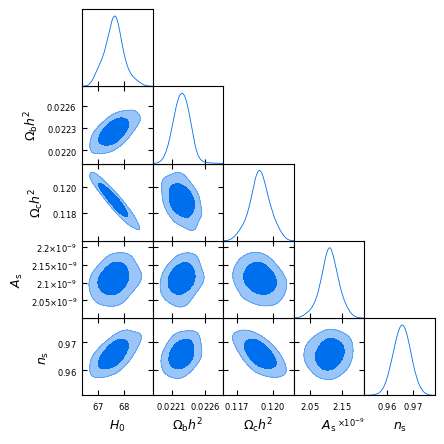

In [5]:
# Load the chains and the updated config file from the previous run
gdsamples = loadMCSamples('chains/lcdm_run')

gdplot_cartesian = gdplt.get_subplot_plotter(width_inch=5)

gdplot_cartesian.triangle_plot(gdsamples, ['H0', 'ombh2', 'omch2', 'As', 'ns'], filled=True)

In [17]:
#Estamos evaluando: P(θ∣datos) en UN SOLO punto

info = {
    #'params': clave protegida de Cobaya del diccionario de entrada.
    # Incluye los parámetros que el usuario quiere usar (o muestrear):
    'params': {
        # Cada parámetro (que es una 'key' de otro diccionario) puede contener
        # cosas como 'prior', 'latex', etc.
        # Si no se define 'prior', el parámetro queda FIJO.
        # En este ejemplo, TODOS los parámetros están fijos.

        'ombh2': 0.022445,  # Densidad de bariones * h^2
        'omch2': 0.1205579307,  # Densidad de materia oscura fría * h^2
        'H0': 67,  # Parámetro de Hubble hoy (km/s/Mpc)
        'tau': 0.0925,  # Profundidad óptica
        'mnu': 0.06,  # Suma de masas de neutrinos (eV)
        'nnu': 3.046,  # Número efectivo de especies relativistas
        'As': 2.12605e-9,  # Amplitud del espectro primordial
        'ns': 0.965,  # Índice espectral primordial
        'w': -1,  # Modelo de energía oscura
        'wa': 0,  # Evolución de la energía oscura
        'omk': 0.0,  # Curvatura

        # Parámetros DERIVADOS (no se muestrean, los calcula Cobaya)
        'omegam': None,  # Densidad total de materia
        'omegab': None,  # Densidad de bariones
        'omeganu': None,  # Densidad de neutrinos
        'omnuh2': None,  # Densidad de neutrinos * h^2
        'omegac': None,  # Densidad de materia oscura
        'N_eff': None
    },

    # 'theory': módulo teórico (solver de Boltzmann)
    # Aquí elegimos CAMB
    'theory': {
        'camb': {
            'stop_at_error': True,
            'extra_args': {
                'num_massive_neutrinos': 1,
                'dark_energy_model': 'ppf'
            }
        }
    },

    # 'sampler': tipo de sampler
    # Aquí usamos 'evaluate' → solo evalúa una vez (NO MCMC)
    'sampler': {
        'evaluate': None
    },

    # 'output': carpeta donde se guardan resultados (si los hay)
    'output': 'chains/euclid_school',

    # 'debug': nivel de detalle de lo que imprime Cobaya
    'debug': False,

    # 'timing': muestra tiempos de ejecución
    'timing': True,

    # 'force': sobrescribe archivos anteriores si existen
    'force': True,
}

In [18]:
# Importamos la likelihood de Planck18
# 'likelihood': clave protegida de Cobaya dentro del diccionario de entrada

info['likelihood'] = {
                'planck_NPIPE_highl_CamSpec.TTTEEE': None}

# Print toda la info!
info

{'params': {'ombh2': 0.022445,
  'omch2': 0.1205579307,
  'H0': 67,
  'tau': 0.0925,
  'mnu': 0.06,
  'nnu': 3.046,
  'As': 2.12605e-09,
  'ns': 0.965,
  'w': -1,
  'wa': 0,
  'omk': 0.0,
  'omegam': None,
  'omegab': None,
  'omeganu': None,
  'omnuh2': None,
  'omegac': None,
  'N_eff': None},
 'theory': {'camb': {'stop_at_error': True,
   'extra_args': {'num_massive_neutrinos': 1, 'dark_energy_model': 'ppf'}}},
 'sampler': {'evaluate': None},
 'output': 'chains/euclid_school',
 'debug': False,
 'timing': True,
 'force': True,
 'likelihood': {'planck_NPIPE_highl_CamSpec.TTTEEE': None}}

In [19]:
# Primero: importamos el wrapper del modelo de Cobaya
from cobaya.model import get_model

# El wrapper `get_model` de Cobaya necesita como argumento
# un diccionario en formato yaml o python

model = get_model(info)

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'force']
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\Lib\site-packages\camb
[planck_npipe_highl_camspec.ttteee] L-range for 143x143: 30 2000
[planck_npipe_highl_camspec.ttteee] L-range for 217x217: 500 2500
[planck_npipe_highl_camspec.ttteee] L-range for 143x217: 500 2500
[planck_npipe_highl_camspec.ttteee] L-range for TE: 30 2000
[planck_npipe_highl_camspec.ttteee] L-range for EE: 30 2000
[planck_npipe_highl_camspec.ttteee] Number of data points: 9915


In [20]:
# Veamos qué le está pidiendo Cobaya a CAMB
# para poder calcular la likelihood de Planck18


# (1) Requerimientos necesarios del código de likelihood
# Es decir, ¿qué cantidades le estamos pidiendo al solver de Boltzmann (CAMB/CLASS)?
print('\n Requirements \n')
print(model.provider.requirement_providers)
# (2) ¿En qué valores se están pidiendo esos requerimientos?
# (por ejemplo: redshift, escalas, etc.)print('\n Requested \n')
print(model.requested())
print('\n Parameters \n')
print(model.input_params) 


 Requirements 

{'Cl': camb, 'CAMB_transfers': camb.transfers}
{'camb.transfers': [{'CAMB_transfers':{'non_linear': False, 'needs_perts': False}}, {'CAMB_transfers':{'non_linear': True, 'needs_perts': True}}], 'camb': [{'omegam':None}, {'omegab':None}, {'omeganu':None}, {'omnuh2':None}, {'omegac':None}, {'N_eff':None}, {'Cl':{'tt': np.int64(2500), 'te': np.int64(2500), 'ee': np.int64(2500)}}]}

 Parameters 

['ombh2', 'omch2', 'H0', 'tau', 'mnu', 'nnu', 'As', 'ns', 'w', 'wa', 'omk', 'A_planck', 'use_fg_residual_model', 'cal0', 'cal2', 'amp_100', 'amp_143', 'amp_217', 'amp_143x217', 'n_100', 'n_143', 'n_217', 'n_143x217', 'calTE', 'calEE']


In [21]:
# Generamos un conjunto aleatorio de valores de parámetros
# (a partir de los priors definidos)

point = dict(zip(model.parameterization.sampled_params(),
                 model.prior.sample(ignore_external=True)[0]))
print('Sampled parameters values: \n', point)
# Calculamos el log-posterior para ese conjunto de parámetros
logposterior = model.logposterior(point)


# Nota: el tiempo se mide solo con fines ilustrativos

print('\n Full log-posterior:')
print('   logposterior: %g' % logposterior.logpost)
print('   logpriors: %r' % dict(zip(list(model.prior), logposterior.logpriors)))
print('   loglikelihoods: %r' % dict(zip(list(model.likelihood), logposterior.loglikes)))
print('   derived params: %r' % dict(zip(list(model.parameterization.derived_params()), logposterior.derived)))

Sampled parameters values: 
 {'A_planck': np.float64(1.001134862500477), 'amp_143': np.float64(43.52681101199789), 'amp_217': np.float64(38.20181021900695), 'amp_143x217': np.float64(32.99033860394477), 'n_143': np.float64(3.1423795873169884), 'n_217': np.float64(4.326253410117374), 'n_143x217': np.float64(0.648300632752648), 'calTE': np.float64(1.000815213410059), 'calEE': np.float64(0.9896245553821903)}

 Full log-posterior:
   logposterior: -19374.6
   logpriors: {'0': np.float64(-4.763998585321588)}
   loglikelihoods: {'planck_NPIPE_highl_CamSpec.TTTEEE': np.float64(-19369.86730716102)}
   derived params: {'omegam': 0.3199995483863335, 'omegab': 0.04999999999999999, 'omeganu': 0.0014365483863335129, 'omnuh2': 0.000644866570625114, 'omegac': 0.26856299999999994, 'N_eff': 3.0460000000000003, 'chi2__CMB': np.float64(38739.73461432204)}


In [30]:
#Grafica el espectro de potencias angular del CMB (temperatura)
# Revisa las líneas anteriores para ver qué requerimientos fueron seleccionados
# por el modelo cuando se especificó Planck18
# En particular, fíjate en model.provider

Cls = model.provider.get_Cl(ell_factor=True, units="muK2")
Cls

{'ell': array([   0,    1,    2, ..., 2548, 2549, 2550], shape=(2551,)),
 'tt': array([   0.        ,    0.        , 1036.70354384, ...,   65.15638534,
          65.02088902,   64.8869541 ], shape=(2551,)),
 'ee': array([0.        , 0.        , 0.05174106, ..., 2.77368874, 2.77233975,
        2.77086767], shape=(2551,)),
 'bb': array([0.00000000e+00, 0.00000000e+00, 1.69431472e-06, ...,
        2.42038561e-02, 2.41713684e-02, 2.41389470e-02], shape=(2551,)),
 'te': array([ 0.        ,  0.        ,  3.41811362, ..., -3.30405357,
        -3.32031719, -3.33661679], shape=(2551,)),
 'et': array([ 0.        ,  0.        ,  3.41811362, ..., -3.30405357,
        -3.32031719, -3.33661679], shape=(2551,))}

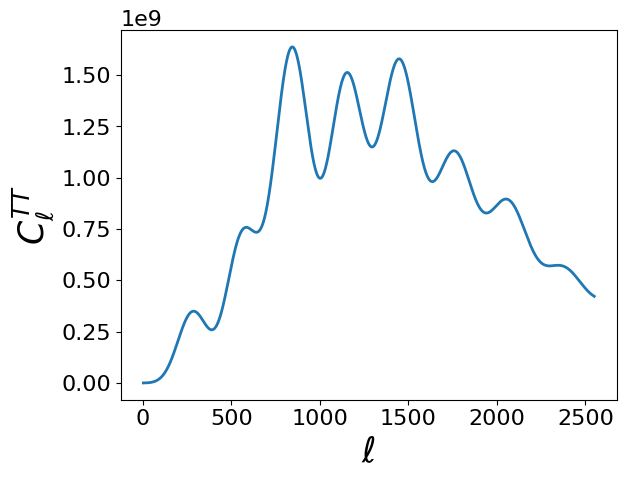

In [31]:
# ¡Ahora vamos a graficarlos!

plt.plot(Cls['ell'][2:], Cls['ell'][2:] * (Cls['ell'][2:] + 1)*Cls['tt'][2:])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell^{TT}$');

In [32]:
#Cambia un parámetro cosmológico (a lo bruto)
#Mira cómo cambia el universo (Espectro de potencias)
#Mira cómo cambia qué tan bien calza con los datos (likelihood)
#info_modified_omegab['params']['ombh2'] = 10 * 0.022445  (multiplicando por 10)


In [33]:
# Hace una copia de info dictionary y modifica la entrada correspondiente a Omega_b
info_modified_omegab = info.copy()
info_modified_omegab['params']['ombh2'] = 10 * 0.022445

In [34]:
# Crear una nueva instancia del modelo usando el diccionario de configuración modificado
model_modified_omegab = get_model(info_modified_omegab)

# Evaluar el posterior para poder solicitar los requerimientos
# Nota: debes hacerlo en el mismo punto que antes
logposterior_modified_omegab = model_modified_omegab.logposterior(point)

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'force']
[camb] `camb` module loaded successfully from C:\Users\yo\miniconda3\Lib\site-packages\camb
[planck_npipe_highl_camspec.ttteee] L-range for 143x143: 30 2000
[planck_npipe_highl_camspec.ttteee] L-range for 217x217: 500 2500
[planck_npipe_highl_camspec.ttteee] L-range for 143x217: 500 2500
[planck_npipe_highl_camspec.ttteee] L-range for TE: 30 2000
[planck_npipe_highl_camspec.ttteee] L-range for EE: 30 2000
[planck_npipe_highl_camspec.ttteee] Number of data points: 9915


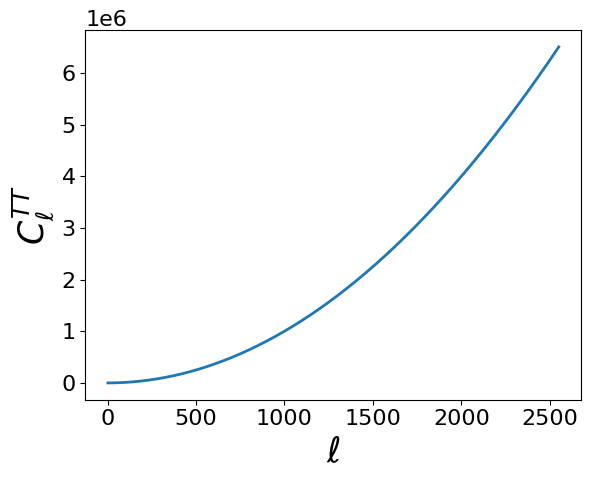

In [35]:
# Graficamos la diferencia en los Cls
Cls_modified_omegab = model_modified_omegab.provider.get_Cl(ell_factor=False, units="muK2")

# Vamos a graficarlo!

plt.plot(Cls_modified_omegab['ell'][2:],
          Cls_modified_omegab['ell'][2:] * (Cls_modified_omegab['ell'][2:] + 1) * (Cls['tt'][2:]-Cls_modified_omegab['tt'][2:])/Cls['tt'][2:])
plt.ylabel(r'$C_\ell^{TT}$');
plt.xlabel(r'$\ell$');

In [36]:
# Calcular la diferencia en los valores de la likelihood para ambos modelos
logposterior.loglike-logposterior_modified_omegab.loglike

np.float64(3093233.300982745)

In [37]:
#1) Elegir un conjunto de parámetros cosmológicos y hacer una corrida con el CAMB para obtener el espectro angular de potencias (C_ell)

#2) Hacer una realización de mapa usando el healpy, con un Nside dado. Cambiar el valor de Nside y comentar los cambios observados en el mapa, manteniendo la misma semilla (seed), para que el mapa tenga un aspecto parecido (sea la misma realización).

#3) Elegir un Nside (por ejemplo, Nside=256) y hacer un histograma de los valores de Temperatura del mapa, es decir, de T(n). Tiene aspecto de distribución gaussiana?

#4) Calcular los momentos angulares de dicho mapa, es decir, los a_lm's. Graficar los histogramas de a_lm, para un ell fijo (tomar algunos valores de referencia y repetir el ejercicio - por ejemplo, ell= 20, 200, 500, 1000)

#5) Calcular el C_ell a partir de mapa con la herramienta anafast, y luego repetir el cálculo a mano, con la fórmula del pseudo-C_ell (es decir, para un dado ell, tomar (Sum_m a_lm)/(2ell+1) ). Comparar los resultados.

#6) Hacer un mapa de foregrounds con el Pysm. Graficarlo. Hacer el histograma de T(n) y mirar su aspecto. Parece una gaussiana?

#Esto quedaba pendiente 